# Ноутбук 04: NER и Question Answering (русскоязычный вариант)

## Часть А: NER
**Задача:** находить в русском тексте людей, организации и локации.

- Модель: `Davlan/bert-base-multilingual-cased-ner-hrl`
- Данные для проверки: `wikiann` (язык `ru`)

## Часть Б: QA
**Задача:** отвечать на вопросы по русскому контексту.

- Модель: `mrm8488/bert-multi-cased-finetuned-xquadv1`
- Оценка: мини-набор русских вопросов с метриками Exact Match и token-F1

- и NER, и QA переведены на русский контекст;
- заменены модели;
- для NER добавлена оценка на wikiann ru;
- для QA добавлены EM и token-F1;
- есть табличный вывод и визуализации


In [1]:
import re
import string

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset
from transformers import pipeline, AutoTokenizer, AutoModelForQuestionAnswering
from huggingface_hub.utils import disable_progress_bars

disable_progress_bars()

device = 0 if torch.cuda.is_available() else -1
print('Устройство:', 'cuda' if device == 0 else 'cpu')


c:\anacon\envs\nlp_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Устройство: cuda


## Часть А: NER

In [2]:
ner_model_id = 'Davlan/bert-base-multilingual-cased-ner-hrl'
ner = pipeline(
    task='token-classification',
    model=ner_model_id,
    aggregation_strategy='first',
    device=device,
)

print('NER-модель загружена:', ner_model_id)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2970.49it/s]
BertForTokenClassification LOAD REPORT from: Davlan/bert-base-multilingual-cased-ner-hrl
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


NER-модель загружена: Davlan/bert-base-multilingual-cased-ner-hrl


Текст:
Сбербанк открыл новый офис в Москве, а Илон Маск посетил Санкт-Петербург и провел встречу с представителями Яндекса.

Найденные сущности:


,word,entity_type,score,start,end
0,Сбербанк,ORG,0.966410,0,8
1,Москве,LOC,0.999853,29,35
2,Илон Маск,PER,0.999814,39,48
3,Санкт - Петербург,LOC,0.999837,57,72
4,Яндекса,ORG,0.999144,108,115


,entity_type,count
0,ORG,2
1,LOC,2
2,PER,1


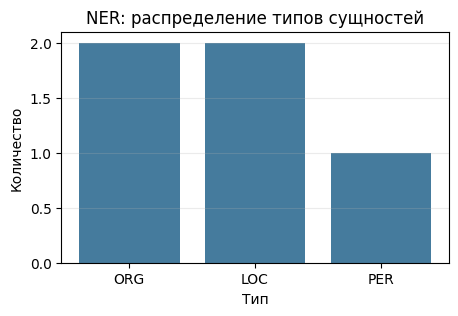

In [3]:
text = (
    'Сбербанк открыл новый офис в Москве, а Илон Маск посетил Санкт-Петербург '
    'и провел встречу с представителями Яндекса.'
)

entities = ner(text)
ner_df = pd.DataFrame(entities)[['word', 'entity_group', 'score', 'start', 'end']]
ner_df = ner_df.rename(columns={'entity_group': 'entity_type'})

print('Текст:')
print(text)
print()
print('Найденные сущности:')
display(ner_df)

entity_counts = ner_df['entity_type'].value_counts().rename_axis('entity_type').reset_index(name='count')
display(entity_counts)

plt.figure(figsize=(5, 3))
plt.bar(entity_counts['entity_type'], entity_counts['count'], color='#457b9d')
plt.title('NER: распределение типов сущностей')
plt.xlabel('Тип')
plt.ylabel('Количество')
plt.grid(axis='y', alpha=0.25)
plt.show()



In [4]:
wikiann = load_dataset('wikiann', 'ru')
label_names = wikiann['train'].features['ner_tags'].feature.names

print('WikiANN (ru):')
print(wikiann)
print('Метки:', label_names)

example = wikiann['train'][0]
print()
print('Пример разметки:')
print('Токены:', example['tokens'])
print('Теги:  ', [label_names[t] for t in example['ner_tags']])



WikiANN (ru):
DatasetDict({
    validation: Dataset({
        features: ['tokens', 'ner_tags', 'langs', 'spans'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['tokens', 'ner_tags', 'langs', 'spans'],
        num_rows: 10000
    })
    train: Dataset({
        features: ['tokens', 'ner_tags', 'langs', 'spans'],
        num_rows: 20000
    })
})
Метки: ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC']

Пример разметки:
Токены: ['Илизаров', ',', 'Гавриил', 'Абрамович']
Теги:   ['B-PER', 'I-PER', 'I-PER', 'I-PER']


In [5]:
def extract_gold_entities(tokens, ner_tags, id2label):
    entities = []
    current_tokens = []
    current_type = None

    for token, tag_id in zip(tokens, ner_tags):
        tag = id2label[tag_id]
        if tag.startswith('B-'):
            if current_tokens:
                entities.append((current_type, ' '.join(current_tokens).lower()))
            current_type = tag[2:]
            current_tokens = [token]
        elif tag.startswith('I-') and current_tokens:
            current_tokens.append(token)
        else:
            if current_tokens:
                entities.append((current_type, ' '.join(current_tokens).lower()))
                current_tokens = []
                current_type = None

    if current_tokens:
        entities.append((current_type, ' '.join(current_tokens).lower()))

    return set(entities)


def extract_pred_entities(preds):
    return set((p['entity_group'], p['word'].lower()) for p in preds)


sample = wikiann['test'].select(range(80))

tp = 0
pred_total = 0
gold_total = 0
shown = 0

for ex in sample:
    tokens = ex['tokens']
    gold = extract_gold_entities(tokens, ex['ner_tags'], label_names)
    if not gold:
        continue

    sentence = ' '.join(tokens)
    pred_raw = ner(sentence)
    pred = extract_pred_entities(pred_raw)

    tp += len(gold & pred)
    pred_total += len(pred)
    gold_total += len(gold)

    if shown < 3:
        print(f'Пример {shown + 1}:')
        print('Текст:', sentence[:180], '...')
        print('Gold:', sorted(list(gold))[:5])
        print('Pred:', sorted(list(pred))[:5])
        print()
        shown += 1

precision = tp / pred_total if pred_total else 0
recall = tp / gold_total if gold_total else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0

print('Приблизительная entity-level оценка на 80 примерах:')
print(f'Precision: {precision:.1%}')
print(f'Recall:    {recall:.1%}')
print(f'F1:        {f1:.1%}')


Пример 1:
Текст: ' '' Крус Асуль '' ' ...
Gold: [('ORG', 'крус асуль')]
Pred: []

Пример 2:
Текст: == Награда Республики Гвинея == ...
Gold: [('LOC', 'республики гвинея')]
Pred: [('LOC', 'республики гвинея')]

Пример 3:
Текст: К тому же сериал ITV Мистер Селфридж был более популярен . ...
Gold: [('ORG', 'itv'), ('ORG', 'мистер селфридж')]
Pred: [('ORG', 'itv')]



You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Приблизительная entity-level оценка на 80 примерах:
Precision: 38.0%
Recall:    45.1%
F1:        41.3%


## Часть Б: Question Answering

In [6]:
qa_model_id = 'mrm8488/bert-multi-cased-finetuned-xquadv1'
qa_tokenizer = AutoTokenizer.from_pretrained(qa_model_id)
qa_model = AutoModelForQuestionAnswering.from_pretrained(qa_model_id)
qa_model.eval()

print('QA-модель загружена:', qa_model_id)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3618.00it/s]
BertForQuestionAnswering LOAD REPORT from: mrm8488/bert-multi-cased-finetuned-xquadv1
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


QA-модель загружена: mrm8488/bert-multi-cased-finetuned-xquadv1


,question,predicted_answer,expected,confidence,exact_match,token_f1
0,В каком году была представлена архитектура Tra...,2017,2017,0.858534,True,1.000000
1,Кто предложил архитектуру Transformer?,Васвани и коллеги из Google Brain,Васвани и коллеги из Google Brain,0.706413,True,1.000000
2,Какова максимальная глубина Байкала?,1642,1642 метра,0.777965,True,1.000000
3,Где находится озеро Байкал?,южной части Восточной Сибири,в южной части Восточной Сибири,0.916137,False,0.888889
4,В каком году основан МГУ?,1755,1755 году,0.775480,True,1.000000
5,Где расположен главный корпус МГУ?,Воробьевых горах в Москве,на Воробьевых горах в Москве,0.855170,False,0.888889


Exact Match: 66.7%
Средний token-F1: 96.3%


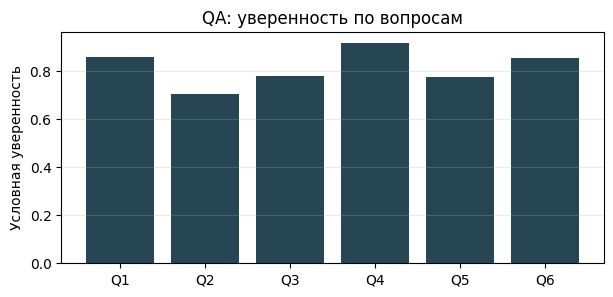

In [7]:
qa_items = [
    {
        'context': 'Архитектура Transformer была представлена в 2017 году в статье «Attention Is All You Need». Авторами считаются Васвани и коллеги из Google Brain. Изначально архитектуру применяли для машинного перевода.',
        'question': 'В каком году была представлена архитектура Transformer?',
        'answers': ['2017'],
    },
    {
        'context': 'Архитектура Transformer была представлена в 2017 году в статье «Attention Is All You Need». Авторами считаются Васвани и коллеги из Google Brain. Изначально архитектуру применяли для машинного перевода.',
        'question': 'Кто предложил архитектуру Transformer?',
        'answers': ['Васвани и коллеги из Google Brain', 'Васвани'],
    },
    {
        'context': 'Озеро Байкал находится в южной части Восточной Сибири и считается самым глубоким озером в мире. Его максимальная глубина составляет 1642 метра. Байкал содержит около 20 процентов мировых запасов пресной поверхностной воды.',
        'question': 'Какова максимальная глубина Байкала?',
        'answers': ['1642 метра', '1642'],
    },
    {
        'context': 'Озеро Байкал находится в южной части Восточной Сибири и считается самым глубоким озером в мире. Его максимальная глубина составляет 1642 метра. Байкал содержит около 20 процентов мировых запасов пресной поверхностной воды.',
        'question': 'Где находится озеро Байкал?',
        'answers': ['в южной части Восточной Сибири', 'в Восточной Сибири'],
    },
    {
        'context': 'МГУ имени М. В. Ломоносова был основан в 1755 году. Главный корпус университета расположен на Воробьевых горах в Москве. МГУ входит в число ведущих университетов России.',
        'question': 'В каком году основан МГУ?',
        'answers': ['1755 году', '1755'],
    },
    {
        'context': 'МГУ имени М. В. Ломоносова был основан в 1755 году. Главный корпус университета расположен на Воробьевых горах в Москве. МГУ входит в число ведущих университетов России.',
        'question': 'Где расположен главный корпус МГУ?',
        'answers': ['на Воробьевых горах в Москве', 'на Воробьевых горах'],
    },
]


def normalize_text(text: str) -> str:
    text = text.lower().replace('ё', 'е')
    punctuation = string.punctuation + '«»—–…'
    text = ''.join(ch for ch in text if ch not in punctuation)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def token_f1(prediction: str, reference: str) -> float:
    pred_tokens = normalize_text(prediction).split()
    ref_tokens = normalize_text(reference).split()

    if not pred_tokens and not ref_tokens:
        return 1.0
    if not pred_tokens or not ref_tokens:
        return 0.0

    counts = {}
    for t in pred_tokens:
        counts[t] = counts.get(t, 0) + 1

    overlap = 0
    for t in ref_tokens:
        if counts.get(t, 0) > 0:
            overlap += 1
            counts[t] -= 1

    if overlap == 0:
        return 0.0

    precision = overlap / len(pred_tokens)
    recall = overlap / len(ref_tokens)
    return 2 * precision * recall / (precision + recall)


def answer_question(question: str, context: str):
    inputs = qa_tokenizer(question, context, return_tensors='pt', truncation=True, max_length=512)
    with torch.no_grad():
        outputs = qa_model(**inputs)

    start_probs = torch.softmax(outputs.start_logits[0], dim=0)
    end_probs = torch.softmax(outputs.end_logits[0], dim=0)

    start_idx = int(torch.argmax(start_probs))
    end_idx = int(torch.argmax(end_probs[start_idx:])) + start_idx

    answer_ids = inputs['input_ids'][0][start_idx:end_idx + 1]
    answer = qa_tokenizer.decode(answer_ids, skip_special_tokens=True).strip()
    confidence = float((start_probs[start_idx] * end_probs[end_idx]).item())
    return answer, confidence


rows = []
for item in qa_items:
    pred_answer, conf = answer_question(item['question'], item['context'])

    pred_norm = normalize_text(pred_answer)
    ref_norms = [normalize_text(r) for r in item['answers']]

    em = pred_norm in ref_norms
    best_f1 = max(token_f1(pred_answer, r) for r in item['answers'])

    rows.append(
        {
            'question': item['question'],
            'predicted_answer': pred_answer,
            'expected': item['answers'][0],
            'confidence': conf,
            'exact_match': em,
            'token_f1': best_f1,
        }
    )

qa_df = pd.DataFrame(rows)
display(qa_df)

print(f'Exact Match: {qa_df["exact_match"].mean():.1%}')
print(f'Средний token-F1: {qa_df["token_f1"].mean():.1%}')

plt.figure(figsize=(7, 3))
plt.bar(range(len(qa_df)), qa_df['confidence'], color='#264653')
plt.xticks(range(len(qa_df)), [f'Q{i + 1}' for i in range(len(qa_df))])
plt.title('QA: уверенность по вопросам')
plt.ylabel('Условная уверенность')
plt.grid(axis='y', alpha=0.25)
plt.show()


In [8]:
context = (
    'Python — высокоуровневый язык программирования общего назначения. '
    'Язык был создан Гвидо ван Россумом и впервые выпущен в 1991 году. '
    'Сегодня Python широко применяется в анализе данных, машинном обучении, веб-разработке и автоматизации.'
)

questions = [
    'Кто создал Python?',
    'Когда вышла первая версия Python?',
    'Где Python применяется сегодня?',
]

print('Контекст:')
print(context)
print()
print('Ответы:')
for q in questions:
    ans, conf = answer_question(q, context)
    print(f'Вопрос: {q}')
    print(f'Ответ:  {ans} (score={conf:.1%})')
    print()



Контекст:
Python — высокоуровневый язык программирования общего назначения. Язык был создан Гвидо ван Россумом и впервые выпущен в 1991 году. Сегодня Python широко применяется в анализе данных, машинном обучении, веб-разработке и автоматизации.

Ответы:
Вопрос: Кто создал Python?
Ответ:  Гвидо ван Россумом (score=93.3%)

Вопрос: Когда вышла первая версия Python?
Ответ:  1991 году (score=79.9%)

Вопрос: Где Python применяется сегодня?
Ответ:  анализе данных, машинном обучении, веб - разработке и автоматизации (score=92.6%)

